# GBS2C2 Lab

Unemployment is when someone loses a job. The rate of unemployment is a key metric of how well a nation’s economy is doing. During the 2020-2022 COVID-19 pandemic, the rate of unemployment rose across the world to unseen numbers. While many areas of the world have started to recover and people have started to go back to work, unemployment still happens. In this activity, we will take a quick look at how unemployment in India is felt by region.

**Copy the code you see in each cell and test the output for yourself!**

**_Note:_** any errors in packages for this project, please use the Anaconda-UI to install what is needed!
___

In [ ]:





import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


#This line of code access data from a comma-seperated-value file (CSV) located in a Github repo using Pandas libray.
data = pd.read_csv("https://raw.githubusercontent.com/amankharwal/Website-data/master/unemployment.csv")


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1077)>

In [2]:
# Using the .head() method, we can get a quick look at the data to ensure it was placed in a Pandas data frame correctly 
data.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [3]:
# Using the .info() method, we can check the names and data types of each column.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1   Date                                      267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [4]:
# As well as viewing the data and types, we should ensure that all values in the data exist. 
print(data.isnull().sum())

Region                                      0
Date                                        0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64


In [5]:
# Using the .columns() method we can rename the columns in our data to better describe what they represent.
data.columns= ["States",
               "Date",
               "Frequency",
               "Estimated Unemployment Rate",
               "Estimated Employed",
               "Estimated Labour Participation Rate",
               "Region",
               "longitude",
               "latitude"]
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   States                               267 non-null    object 
 1   Date                                 267 non-null    object 
 2   Frequency                            267 non-null    object 
 3   Estimated Unemployment Rate          267 non-null    float64
 4   Estimated Employed                   267 non-null    int64  
 5   Estimated Labour Participation Rate  267 non-null    float64
 6   Region                               267 non-null    object 
 7   longitude                            267 non-null    float64
 8   latitude                             267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


Using a heat map, we can determin if there is any correlation (relationship) between the values in our different columns. 
You will learn more about what this means in our next few classes but for now, just know that we can use Pandas to check the values against one another to determine any sort of relationship using the .cor() method


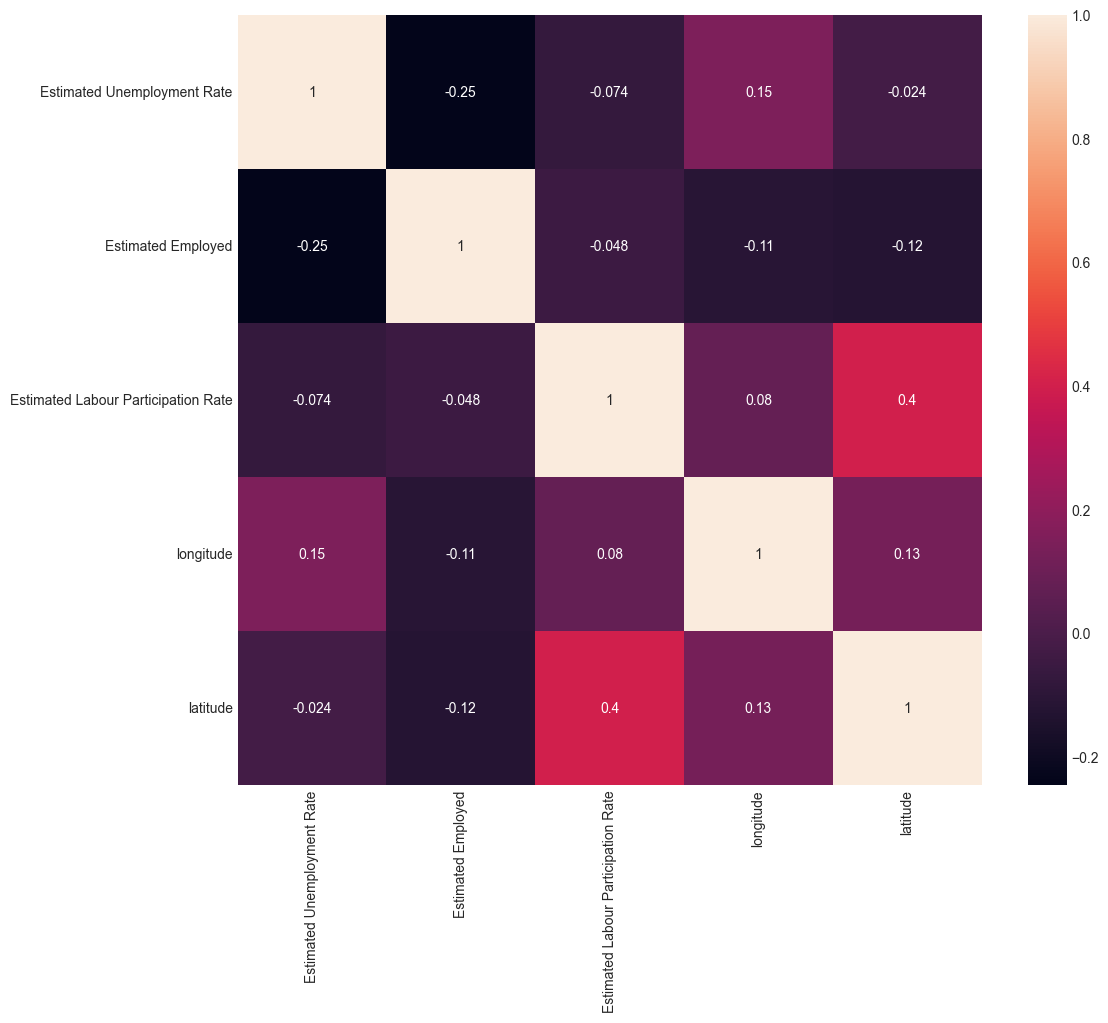

In [7]:
# Note: plt is the name we have given our matplotlib library. we use 'plt' to display data in charts and graphs such as the sns.heatmap() method
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(12, 10))
corr = data.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True)
plt.show()

You will notice in the above heatmap that each column is represented on both the 'x' and 'y' axis. With that, you can look at each cell and see how much of a correlation (relationship) is present with specific column/row pairs. Notice that the instances where the cell is the same column, there is always a positive relationship!

_Note:_ When things (2 pieces of data) correlate, that means a change in one gives change to another. An example of correlation could be the time you have gone without a hair cut and the length of your hair. As the time increases, the length of your hair will increase. We will discuss correlation in much more detail later on in this sprint as it is key to data science!

___
Using a histogram, we can view the distrobution of data across all cells. Using Matplotlib, this is easy a looks great!
Take a look at the plt.title() method and determine what this chart is showing.

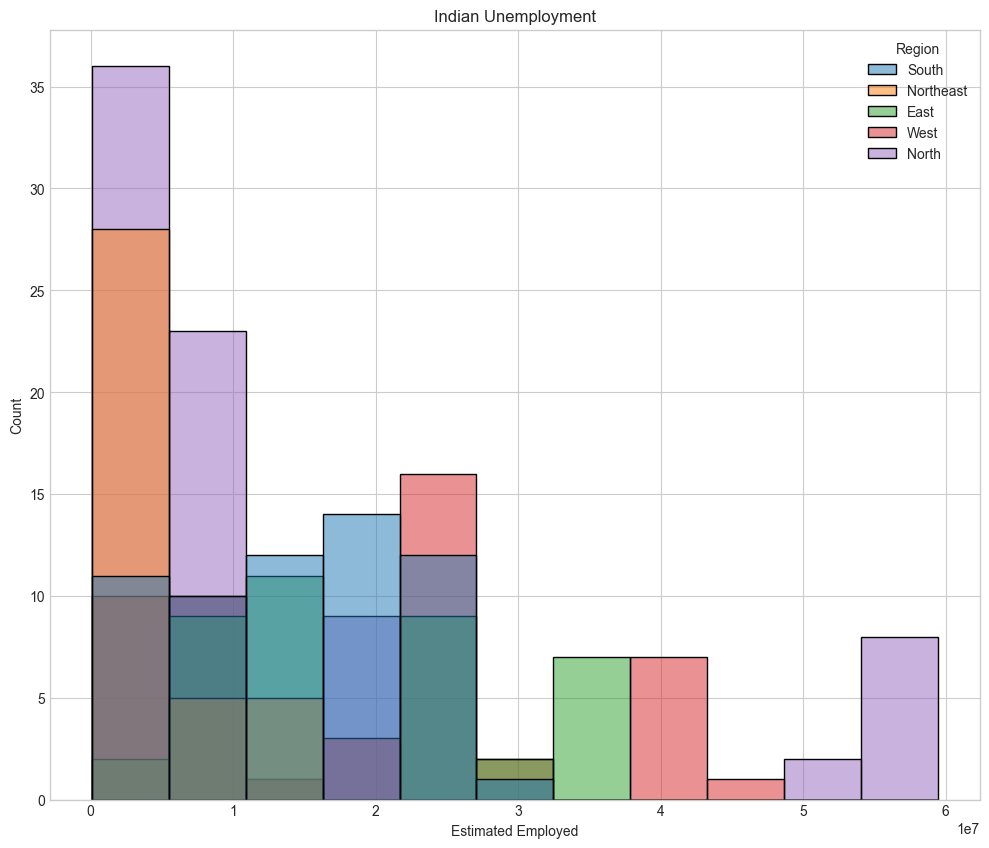

In [8]:
plt.figure(figsize=(12, 10))
plt.title("Indian Unemployment")
sns.histplot(x="Estimated Employed", hue="Region", data=data)
plt.show()

This histogram might be hard to read, this is becuase the data is 5 overlapping columns of data on one chart. Each region (sorted by color) is being displayed from across the chart but the distrobution level are different. For example the North has the bulk of the data being distributed at the low and high end of the chart while the West region's bulk of distrobution is located in the center.

___
**Challenge:** Please create the same chart but this time, display the distribution of data for "Indian Unemployment".

Write your code in the empty cell below.

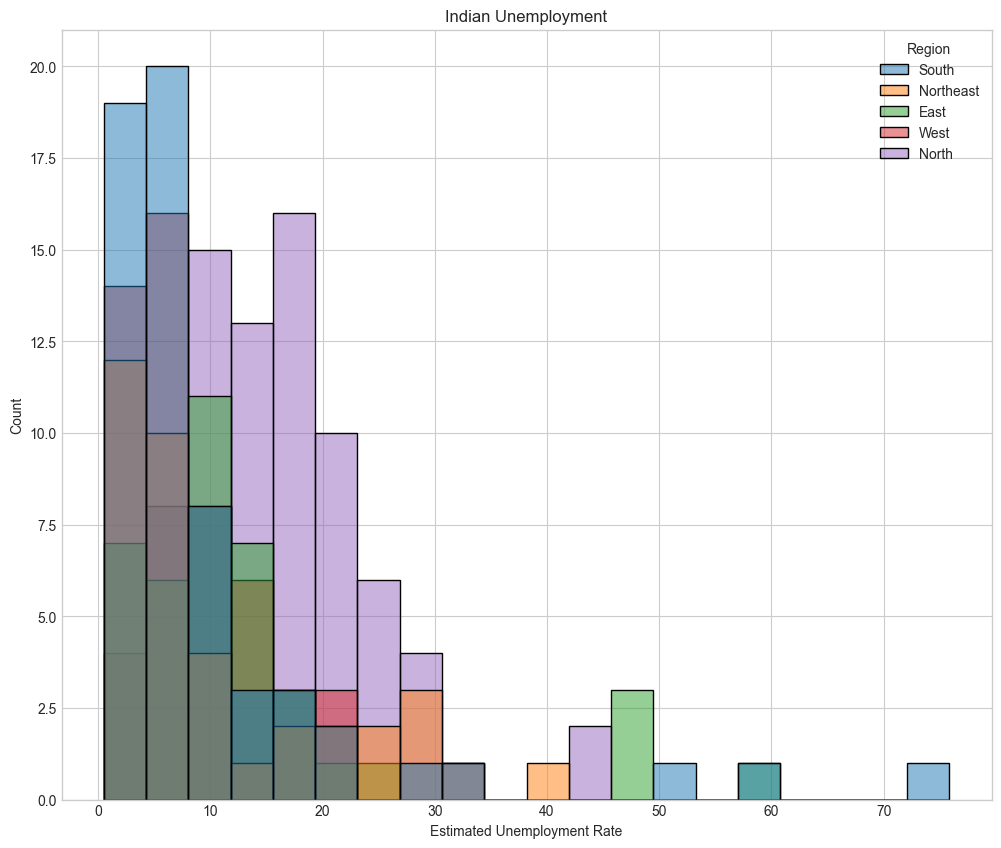

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
plt.title("Indian Unemployment")
sns.histplot(x="Estimated Unemployment Rate", hue="Region", data=data, bins=20)
plt.show()

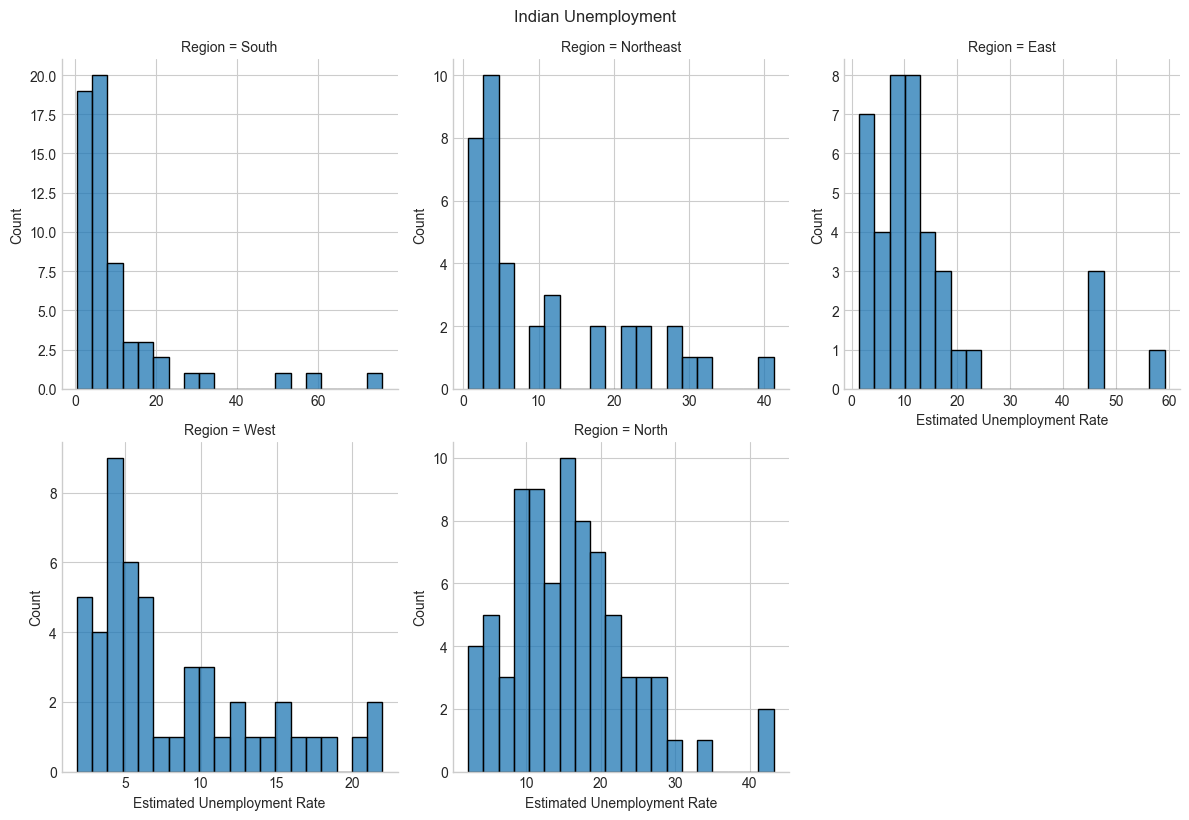

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(data, col="Region", col_wrap=3, height=4, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x="Estimated Unemployment Rate", bins=20)

g.fig.suptitle("Indian Unemployment", y=1.02)  # title for the whole grid
plt.show()


Finally, here is a fun way to display data in what is called a 'sun-burst' dashboad. Please just follow the code to see the really cool output.

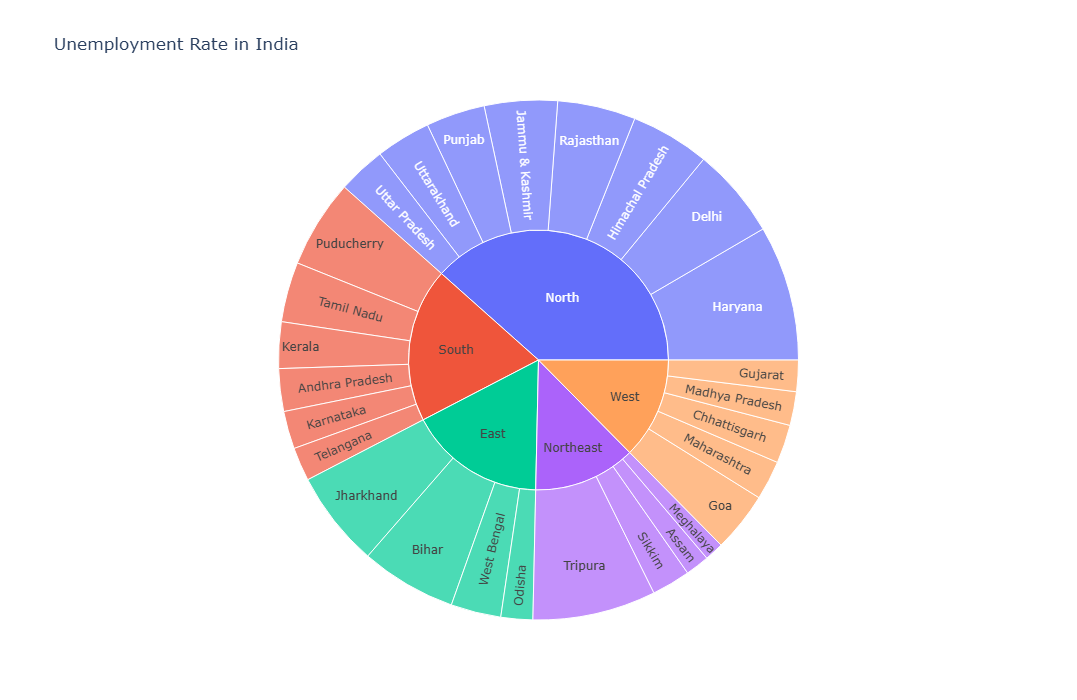

In [11]:
unemploment = data[["States", "Region", "Estimated Unemployment Rate"]]
figure = px.sunburst(unemploment, path=["Region", "States"], 
                     values="Estimated Unemployment Rate", 
                     width=700, height=700, color_continuous_scale="RdY1Gn", 
                     title="Unemployment Rate in India")
figure.show()

Notice, this dashboard is interactive, hover your mouse over each sector and you will see the data in its particular grouping